# 이질적 처치 효과 (HTE)

타노스는 우주 인구의 절반을 무작위로 제거했다가 실패했습니다. 히어로들이 되돌려 버렸으니까요.

타노스 주니어는 달랐습니다. 무작위 제거 대신, 제거했을 때 범죄율이 가장 크게 **증가**하는 지역을 골라 제거하겠다는 전략을 세웠습니다. 제거 후 혼란으로 범죄가 늘어난 지역이 남으면 세계가 더 빠르게 무너진다는 계산입니다.

그런데 전략을 세우려면 먼저 이 질문에 답해야 합니다.

**어느 지역에서 제거를 실행하면 범죄율이 가장 많이 증가하는가?**

## 설정

타노스 주니어는 300개 지역을 관찰합니다. 절반은 무작위로 제거 대상(T=1)으로 지정해 파일럿 실험을 합니다. 나머지 절반은 통제 지역(T=0)으로 둡니다. 제거 이후 각 지역의 범죄율 변화(crime_change)를 측정합니다.

| 변수 | 의미 |
|------|------|
| poverty_rate | 빈곤율 |
| police_density | 경찰 밀도 |
| hero_density | 히어로 출몰 빈도 |
| population_density | 인구 밀도 |
| gang_activity | 갱 활동 지수 |
| snapped | 제거 여부 (T=1: 제거, T=0: 통제) |
| crime_change | 범죄율 변화 (양수 = 범죄 증가 = 타노스 주니어의 목표) |

## 반사실 문제

타노스 주니어가 각 지역의 처치 효과를 정확히 알려면, 같은 지역을 제거한 세계와 제거하지 않은 세계에서 동시에 관찰해야 합니다. 지구가 두 개여야 가능한 일입니다.

이것이 반사실(counterfactual) 문제이고, 지역별 처치 효과(ITE)를 직접 계산하지 못하는 이유입니다.

$$\text{ITE}_i = Y_i(1) - Y_i(0)$$

| 지역 | 제거 여부 | Y(1) 제거 시 | Y(0) 미제거 시 | ITE |
|------|-----------|------------|--------------|-----|
| 지역 A | 제거됨 | 관찰 가능 | 관찰 불가 | 계산 불가 |
| 지역 B | 통제 | 관찰 불가 | 관찰 가능 | 계산 불가 |

그래서 개별 ITE 대신 집단 평균인 ATE를 추정합니다.

$$\text{ATE} = \mathbb{E}[Y(1) - Y(0)]$$

그런데 ATE에는 한계가 있습니다. 지역마다 처치 효과가 달라도 평균이 이를 가려버립니다. 이 이질성을 분석하는 것이 HTE이고, 특성 X를 조건으로 수치화한 것이 CATE입니다.

| 개념 | 정의 |
|------|------|
| ITE | 지역별 처치 효과 — 직접 관측 불가 |
| ATE | ITE의 전체 평균 — 이질성 무시 |
| HTE | ITE가 지역마다 다른 현상 |
| CATE | 특성 X별 ITE 평균 — HTE를 수치화 |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from numpy.linalg import lstsq
from pathlib import Path

_data = Path('thanos_junior.csv')
if not _data.exists():
    _data = Path('book/hte/thanos_junior.csv')
df = pd.read_csv(_data)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [ ]:
df.head()

## 1단계 — ATE: 전체 평균 처치 효과

일단 전체 그림을 봅니다.

$$\text{ATE} = \mathbb{E}[Y \mid T=1] - \mathbb{E}[Y \mid T=0]$$

제거된 지역과 통제 지역의 평균 범죄율 변화를 단순 비교합니다. 타노스 주니어에게는 이 값이 양수(+)여야 성공입니다.

통제 지역 평균 범죄 변화: +1.12
제거 지역 평균 범죄 변화: -0.15
ATE: -1.27


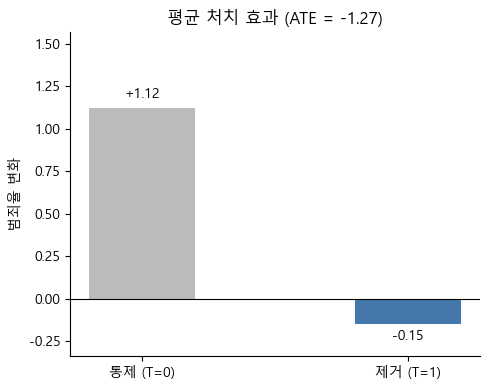

In [ ]:
mean_t0 = df.loc[df['snapped'] == 0, 'crime_change'].mean()
mean_t1 = df.loc[df['snapped'] == 1, 'crime_change'].mean()
ate = mean_t1 - mean_t0

print(f'통제 지역 평균 범죄 변화: {mean_t0:+.2f}')
print(f'제거 지역 평균 범죄 변화: {mean_t1:+.2f}')
print(f'ATE: {ate:+.2f}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ['통제 (T=0)', '제거 (T=1)'],
    [mean_t0, mean_t1],
    color=['#BBBBBB', '#4477AA'],
    width=0.4,
)
ax.axhline(0, color='black', linewidth=0.8)
y_vals = [mean_t0, mean_t1]
y_range = max(y_vals) - min(y_vals)
ax.set_ylim(min(y_vals) - y_range * 0.15, max(y_vals) + y_range * 0.35)
for i, v in enumerate(y_vals):
    if v >= 0:
        ax.text(i, v + y_range * 0.03, f'{v:+.2f}', ha='center', va='bottom')
    else:
        ax.text(i, v - y_range * 0.03, f'{v:+.2f}', ha='center', va='top')
ax.set_ylabel('범죄율 변화')
ax.set_title(f'평균 처치 효과 (ATE = {ate:+.2f})')
plt.tight_layout()
plt.show()

## 2단계 — HTE: 효과는 모든 지역에서 같았을까?

ATE가 음수라면 타노스 주니어의 작전은 실패처럼 보입니다. 하지만 정말 모든 지역에서 범죄가 줄었을까요?

산점도를 보겠습니다.

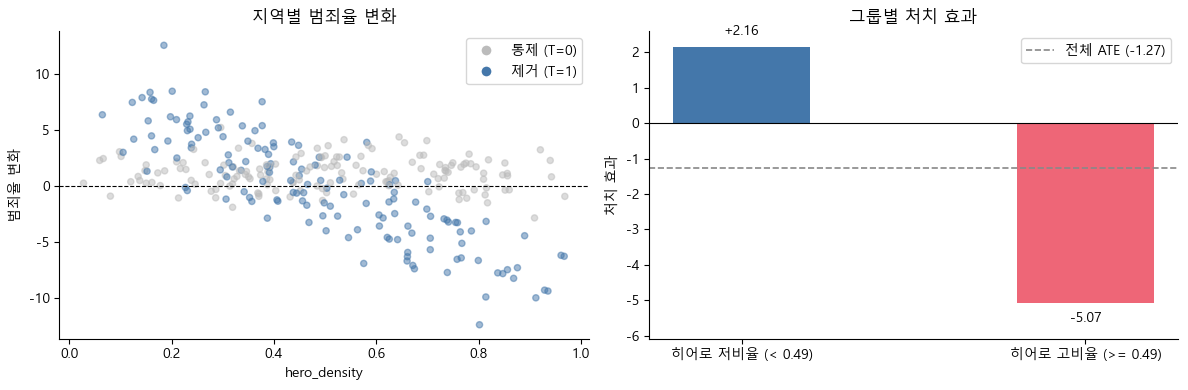

In [ ]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
color_map = {0: '#BBBBBB', 1: '#4477AA'}
point_colors = [color_map[s] for s in df['snapped']]
ax.scatter(df['hero_density'], df['crime_change'], c=point_colors, alpha=0.5, s=20)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('hero_density')
ax.set_ylabel('범죄율 변화')
ax.set_title('지역별 범죄율 변화')
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#BBBBBB', markersize=8, label='통제 (T=0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4477AA', markersize=8, label='제거 (T=1)'),
]
ax.legend(handles=legend_elements)

median_hero = df['hero_density'].median()
groups = {
    f'히어로 저비율 (< {median_hero:.2f})': df[df['hero_density'] < median_hero],
    f'히어로 고비율 (>= {median_hero:.2f})': df[df['hero_density'] >= median_hero],
}
stats = {}
for label, g in groups.items():
    t0_mean = g[g['snapped'] == 0]['crime_change'].mean()
    t1_mean = g[g['snapped'] == 1]['crime_change'].mean()
    stats[label] = {'T0': t0_mean, 'T1': t1_mean, 'effect': t1_mean - t0_mean}

COLORS = ['#4477AA', '#EE6677']
ax = axes[1]
labels = list(stats.keys())
effects = [stats[l]['effect'] for l in labels]
ax.bar(labels, effects, color=COLORS, width=0.4)
ax.axhline(ate, color='#888888', linestyle='--', linewidth=1.2, label=f'전체 ATE ({ate:+.2f})')
ax.axhline(0, color='black', linewidth=0.8)
y_min = min(effects)
y_max = max(effects)
ax.set_ylim(y_min - abs(y_min) * 0.2, max(y_max + abs(y_max) * 0.2, 0.4))
ax.set_ylabel('처치 효과')
ax.set_title('그룹별 처치 효과')
for i, v in enumerate(effects):
    if v >= 0:
        ax.text(i, v + abs(y_min) * 0.05, f'{v:+.2f}', ha='center', va='bottom')
    else:
        ax.text(i, v - abs(y_min) * 0.05, f'{v:+.2f}', ha='center', va='top')
ax.legend()

plt.tight_layout()
plt.show()

## 3단계 — CATE: HTE를 연속적으로 수치화하기

그룹 비교로는 "두 그룹이 다르다"는 것만 확인했습니다. 상호작용 모델을 쓰면 특성 X에 따라 처치 효과가 어떻게 달라지는지 연속적으로 추정할 수 있습니다.

$$Y = \beta_0 + \beta_1 T + \beta_2 X + \beta_3 (T \times X) + \varepsilon$$

$$\text{CATE}(X) = \beta_1 + \beta_3 \cdot X$$

$\beta_1$은 X와 무관한 기본 처치 효과이고, $\beta_3$는 X가 1 증가할 때 처치 효과가 변하는 크기입니다.

| $\beta_3$의 부호 | 의미 |
|-----------|------|
| $\beta_3 > 0$ | X가 클수록 처치 효과 증가 |
| $\beta_3 < 0$ | X가 클수록 처치 효과 감소 |
| $\beta_3 \approx 0$ | HTE 없음 — ATE로 충분 |

점 추정치만이 아니라 신뢰구간도 함께 봅니다. OLS 분산-공분산 행렬에서 직접 계산합니다.

$$\text{SE}(\text{CATE}(x)) = \sqrt{\text{Var}(\beta_1) + x^2 \cdot \text{Var}(\beta_3) + 2x \cdot \text{Cov}(\beta_1, \beta_3)}$$

beta_T (기본 처치 효과): +7.604
beta_TX (hero_density당 효과 변화): -18.245
CATE = 0 이 되는 지점: hero_density = 0.42

hero_density=0.20 (p10): CATE=+4.00, 95% CI [+3.25, +4.75]
hero_density=0.49 (p50): CATE=-1.28, 95% CI [-1.73, -0.82]
hero_density=0.80 (p90): CATE=-7.03, 95% CI [-7.80, -6.27]


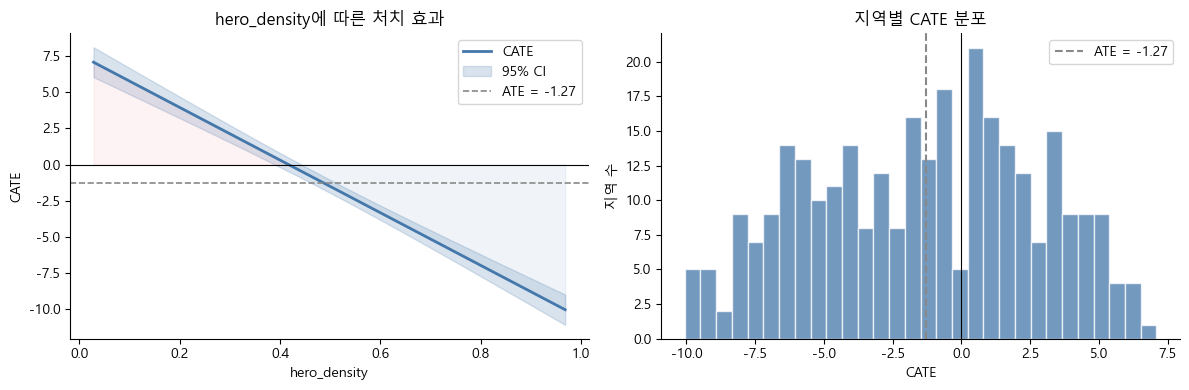

In [ ]:
T_arr = df['snapped'].values
Y_arr = df['crime_change'].values
n = len(Y_arr)

X_arr = df['hero_density'].values
X_mat = np.column_stack([np.ones(n), T_arr, X_arr, T_arr * X_arr])
coef, _, _, _ = lstsq(X_mat, Y_arr, rcond=None)
beta0, beta_T, beta_X, beta_TX = coef

residuals = Y_arr - X_mat @ coef
sigma2 = np.sum(residuals ** 2) / (n - 4)
cov_mat = sigma2 * np.linalg.inv(X_mat.T @ X_mat)

print(f'beta_T (기본 처치 효과): {beta_T:+.3f}')
print(f'beta_TX (hero_density당 효과 변화): {beta_TX:+.3f}')
print(f'CATE = 0 이 되는 지점: hero_density = {-beta_T / beta_TX:.2f}')
print()
for pct, label in [(0.10, 'p10'), (0.50, 'p50'), (0.90, 'p90')]:
    x = float(np.quantile(X_arr, pct))
    cate_val = beta_T + beta_TX * x
    se = np.sqrt(cov_mat[1, 1] + x ** 2 * cov_mat[3, 3] + 2 * x * cov_mat[1, 3])
    print(f'hero_density={x:.2f} ({label}): CATE={cate_val:+.2f}, 95% CI [{cate_val - 1.96 * se:+.2f}, {cate_val + 1.96 * se:+.2f}]')

x_range = np.linspace(X_arr.min(), X_arr.max(), 200)
cate_line = beta_T + beta_TX * x_range
se_line = np.sqrt(cov_mat[1, 1] + x_range ** 2 * cov_mat[3, 3] + 2 * x_range * cov_mat[1, 3])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x_range, cate_line, color='#4477AA', linewidth=2, label='CATE')
ax.fill_between(
    x_range,
    cate_line - 1.96 * se_line,
    cate_line + 1.96 * se_line,
    alpha=0.2,
    color='#4477AA',
    label='95% CI',
)
ax.axhline(ate, color='#888888', linestyle='--', linewidth=1.2, label=f'ATE = {ate:+.2f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(x_range, cate_line, 0, where=(cate_line > 0), alpha=0.08, color='#EE6677')
ax.fill_between(x_range, cate_line, 0, where=(cate_line <= 0), alpha=0.08, color='#4477AA')
ax.set_xlabel('hero_density')
ax.set_ylabel('CATE')
ax.set_title('hero_density에 따른 처치 효과')
ax.legend()

ax = axes[1]
cate_vals = beta_T + beta_TX * X_arr
ax.hist(cate_vals, bins=30, color='#4477AA', alpha=0.75, edgecolor='white')
ax.axvline(ate, color='#888888', linestyle='--', label=f'ATE = {ate:+.2f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('CATE')
ax.set_ylabel('지역 수')
ax.set_title('지역별 CATE 분포')
ax.legend()

plt.tight_layout()
plt.show()

### poverty_rate에 따른 처치 효과

CATE는 어떤 변수든 조절 변수로 쓸 수 있습니다. hero_density 대신 poverty_rate로 바꿔봅니다.

빈곤율이 높은 지역은 제거 후 자원 부족으로 범죄가 늘어날 수 있습니다. 단, 이 가설이 실제 데이터에서도 유의미한지는 신뢰구간을 함께 봐야 합니다.

beta_T (기본 처치 효과): -4.252
beta_TX (poverty_rate당 효과 변화): +7.293

poverty_rate=0.14 (p10): CATE=-3.20, 95% CI [-4.39, -2.00]
poverty_rate=0.37 (p50): CATE=-1.57, 95% CI [-2.31, -0.83]
poverty_rate=0.64 (p90): CATE=+0.42, 95% CI [-0.81, +1.65]


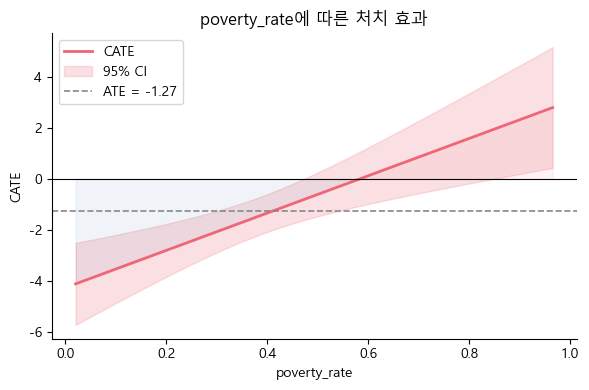

In [ ]:
X_arr2 = df['poverty_rate'].values
X_mat2 = np.column_stack([np.ones(n), T_arr, X_arr2, T_arr * X_arr2])
coef2, _, _, _ = lstsq(X_mat2, Y_arr, rcond=None)
beta0_2, beta_T2, beta_X2, beta_TX2 = coef2

residuals2 = Y_arr - X_mat2 @ coef2
sigma2_2 = np.sum(residuals2 ** 2) / (n - 4)
cov_mat2 = sigma2_2 * np.linalg.inv(X_mat2.T @ X_mat2)

print(f'beta_T (기본 처치 효과): {beta_T2:+.3f}')
print(f'beta_TX (poverty_rate당 효과 변화): {beta_TX2:+.3f}')
print()
for pct, label in [(0.10, 'p10'), (0.50, 'p50'), (0.90, 'p90')]:
    x = float(np.quantile(X_arr2, pct))
    cate_val = beta_T2 + beta_TX2 * x
    se = np.sqrt(cov_mat2[1, 1] + x ** 2 * cov_mat2[3, 3] + 2 * x * cov_mat2[1, 3])
    print(f'poverty_rate={x:.2f} ({label}): CATE={cate_val:+.2f}, 95% CI [{cate_val - 1.96 * se:+.2f}, {cate_val + 1.96 * se:+.2f}]')

x_range2 = np.linspace(X_arr2.min(), X_arr2.max(), 200)
cate_line2 = beta_T2 + beta_TX2 * x_range2
se_line2 = np.sqrt(cov_mat2[1, 1] + x_range2 ** 2 * cov_mat2[3, 3] + 2 * x_range2 * cov_mat2[1, 3])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_range2, cate_line2, color='#EE6677', linewidth=2, label='CATE')
ax.fill_between(
    x_range2,
    cate_line2 - 1.96 * se_line2,
    cate_line2 + 1.96 * se_line2,
    alpha=0.2,
    color='#EE6677',
    label='95% CI',
)
ax.axhline(ate, color='#888888', linestyle='--', linewidth=1.2, label=f'ATE = {ate:+.2f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(x_range2, cate_line2, 0, where=(cate_line2 > 0), alpha=0.08, color='#EE6677')
ax.fill_between(x_range2, cate_line2, 0, where=(cate_line2 <= 0), alpha=0.08, color='#4477AA')
ax.set_xlabel('poverty_rate')
ax.set_ylabel('CATE')
ax.set_title('poverty_rate에 따른 처치 효과')
ax.legend()
plt.tight_layout()
plt.show()

## 왜 ATE만 보면 안 되는가

타노스 주니어가 ATE만 봤다면 이렇게 결론 내렸을 겁니다.

> "제거했더니 범죄가 오히려 줄었다. 작전 실패."

그런데 실제로는 이야기가 다릅니다.

| 집단 | 처치 효과 |
|------|----------|
| 히어로 저비율 지역 | 약 +2 (범죄 증가 — 타노스 주니어의 목표) |
| 히어로 고비율 지역 | 약 -5 (범죄 크게 감소 — 최악의 타겟) |

ATE는 -1.3이지만, 히어로 저비율 지역에서는 범죄가 오히려 늘어납니다. 처음부터 히어로 저비율 지역만 골라 제거했더라면 목표를 달성할 수 있었습니다.

poverty_rate도 조절 변수 후보였지만, 빈곤율 상위 10% 지역의 신뢰구간이 0을 포함해 (+0.42, CI [-0.81, +1.65]) 통계적으로 불확실합니다. hero_density가 훨씬 선명한 조절 변수입니다.

이것이 HTE가 중요한 이유입니다. ATE는 "평균적으로 효과 있는가"를 알려주지만, 누구에게 효과가 있는지는 알려주지 않습니다.

---

| 개념 | 핵심 질문 |
|------|----------|
| ATE | 처치가 전반적으로 효과 있는가? |
| HTE | 처치 효과가 지역마다 다른가? |
| CATE | 특성 X를 가진 지역에 얼마나 효과적인가? |